In [8]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('ecommerce_sales_data.csv')
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


# Duplicating dataset

In [11]:
df1 = df.copy()
df1

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


# Information of dataset

In [13]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


# Desciption of dataset

In [15]:
df1.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


# To check nullvalues

In [17]:
df1.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

# To check duplicate in dataset

In [19]:
df1.duplicated().sum()

0

# Customers regional distribution

C:\Users\USER\AppData\Local\Temp\ipykernel_14120\1793051605.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df1, x='Region', palette='pastel', edgecolor='black')


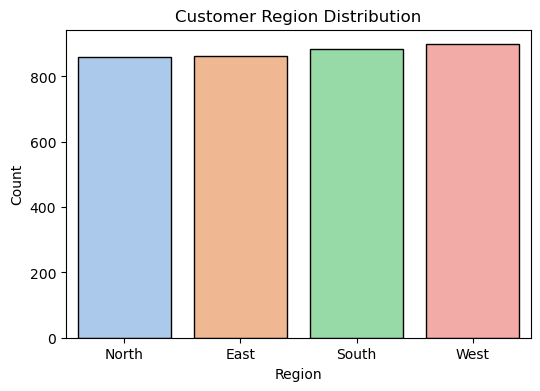

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df1, x='Region', palette='pastel', edgecolor='black')

plt.title('Customer Region Distribution')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

# Average sales by quantity

C:\Users\USER\AppData\Local\Temp\ipykernel_14120\2773683285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1, x='Quantity', y='Sales',


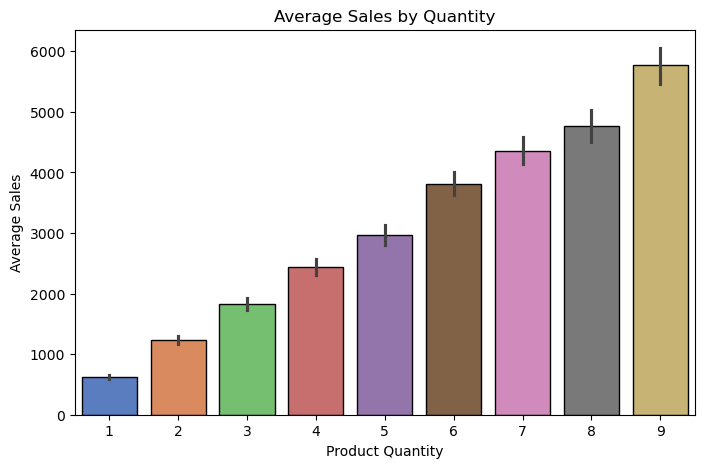

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(data=df1, x='Quantity', y='Sales', 
            estimator='mean', palette='muted', edgecolor='black')

plt.title('Average Sales by Quantity')
plt.xlabel('Product Quantity')
plt.ylabel('Average Sales')
plt.show()

# Sales by category

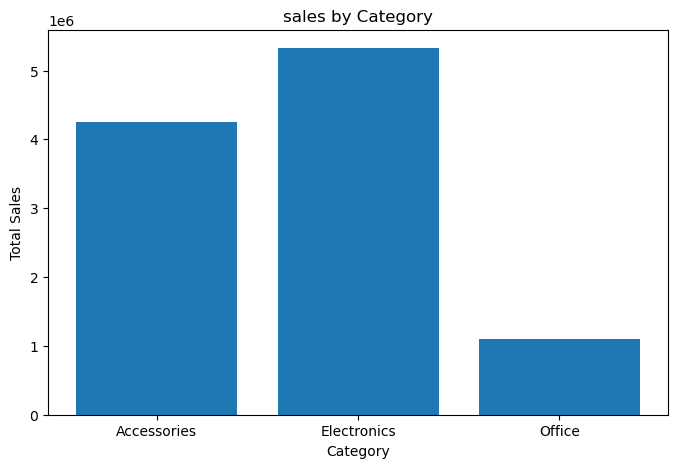

In [25]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,5))
plt.bar(category_sales.index,category_sales.values)
plt.title('sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

# Profit by region

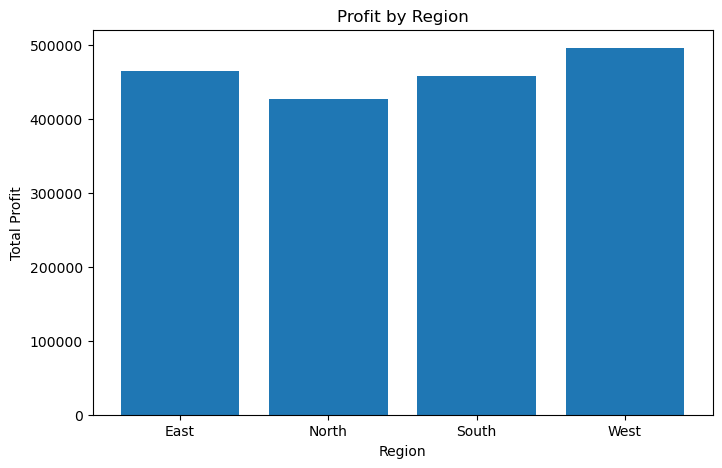

In [27]:
region_profit = df.groupby('Region')['Profit'].sum()
plt.figure(figsize=(8,5))
plt.bar(region_profit.index,region_profit.values)
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

# Top selling products

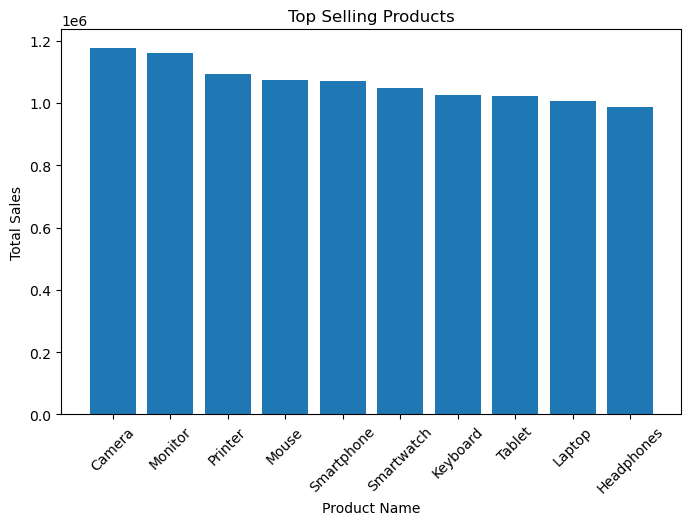

In [29]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(top_products.index,top_products.values)
plt.title('Top Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [30]:
df1['Order Date'] = pd.to_datetime(df['Order Date']) # converting date column
df1

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


# Quantity sold by category

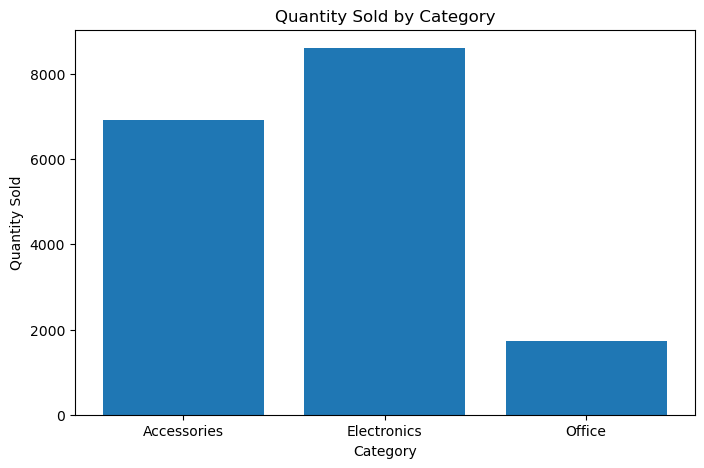

In [32]:
quantity_category = df.groupby('Category')['Quantity'].sum()
plt.figure(figsize=(8,5))
plt.bar(quantity_category.index,quantity_category.values)
plt.title('Quantity Sold by Category')
plt.xlabel('Category')
plt.ylabel('Quantity Sold')
plt.show()

# Profit vs sales relationship

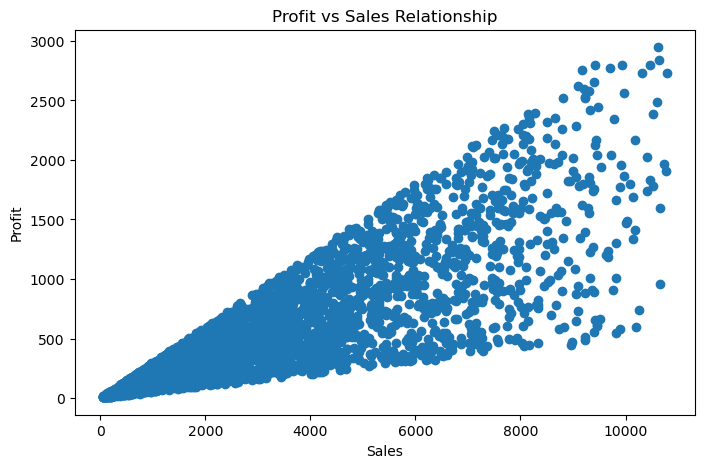

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df1['Sales'],df1['Profit'])
plt.title('Profit vs Sales Relationship')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

# Machine learning

# Prepare the data with Label Encoder

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df1.select_dtypes(include = 'object').columns:
    df1[col] = le.fit_transform(df1[col].astype(str))
print(df1.head)


<bound method NDFrame.head of      Order Date  Product Name  Category  Region  Quantity  Sales   Profit
0    2024-12-31             6         2       1         4   3640   348.93
1    2022-11-27             5         0       0         7   1197   106.53
2    2022-05-11             9         1       2         5   5865   502.73
3    2024-03-16             5         0       2         2    786   202.87
4    2022-09-10             5         0       3         1    509   103.28
...         ...           ...       ...     ...       ...    ...      ...
3495 2023-02-15             4         0       1         4   4064   771.16
3496 2022-09-18             4         0       0         1   1117   119.89
3497 2022-04-12             3         1       2         4    260    66.02
3498 2022-01-18             6         2       2         3    222    50.28
3499 2024-11-01             8         1       0         9  10530  1777.32

[3500 rows x 7 columns]>


# Spicting x and y

In [39]:
X = df1.drop('Profit',axis = 1)
Y = df1['Profit']
X

,Order Date,Product Name,Category,Region,Quantity,Sales
0,2024-12-31,6,2,1,4,3640
1,2022-11-27,5,0,0,7,1197
2,2022-05-11,9,1,2,5,5865
3,2024-03-16,5,0,2,2,786
4,2022-09-10,5,0,3,1,509
...,...,...,...,...,...,...
3495,2023-02-15,4,0,1,4,4064
3496,2022-09-18,4,0,0,1,1117
3497,2022-04-12,3,1,2,4,260
3498,2022-01-18,6,2,2,3,222


In [40]:
Y

0        348.93
1        106.53
2        502.73
3        202.87
4        103.28
         ...   
3495     771.16
3496     119.89
3497      66.02
3498      50.28
3499    1777.32
Name: Profit, Length: 3500, dtype: float64

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
X_train

,Order Date,Product Name,Category,Region,Quantity,Sales
162,2024-03-24,9,1,1,9,7452
1001,2024-04-29,2,0,1,2,310
1718,2024-04-07,7,1,2,4,2380
1003,2024-10-22,9,1,3,3,2832
1233,2024-04-29,3,1,3,6,2520
...,...,...,...,...,...,...
1095,2023-06-27,9,1,0,4,844
1130,2022-04-15,3,1,0,1,166
1294,2022-10-20,6,2,3,1,98
860,2023-08-30,9,1,2,8,5176


In [42]:
X_test

,Order Date,Product Name,Category,Region,Quantity,Sales
1650,2024-12-28,8,1,1,5,3625
2456,2022-06-10,9,1,0,5,5160
2232,2022-12-09,1,0,2,1,355
1945,2023-04-25,0,1,2,7,3136
309,2024-06-05,2,0,2,6,3648
...,...,...,...,...,...,...
3127,2023-02-13,8,1,0,2,2334
744,2022-07-29,1,0,3,3,2535
631,2024-05-02,4,0,2,5,3490
1557,2022-06-04,0,1,0,5,4235


In [43]:
Y_train

162     1212.51
1001      70.66
1718     594.86
1003     317.76
1233     182.59
         ...   
1095     136.02
1130       9.69
1294      28.57
860      866.36
3174    1288.04
Name: Profit, Length: 2800, dtype: float64

In [44]:
Y_test

1650     245.52
2456     698.15
2232      26.80
1945     850.30
309     1050.08
         ...   
3127     158.07
744      292.19
631      205.04
1557     747.96
2213    1029.92
Name: Profit, Length: 700, dtype: float64

In [45]:
print(df1.columns)

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')


In [46]:
X = df1.drop('Profit',axis=1)
Y = df1['Profit']
print(X.head())

  Order Date  Product Name  Category  Region  Quantity  Sales
0 2024-12-31             6         2       1         4   3640
1 2022-11-27             5         0       0         7   1197
2 2022-05-11             9         1       2         5   5865
3 2024-03-16             5         0       2         2    786
4 2022-09-10             5         0       3         1    509


In [47]:
print(Y.head())

0    348.93
1    106.53
2    502.73
3    202.87
4    103.28
Name: Profit, dtype: float64


In [48]:
print(X_train.dtypes)

Order Date      datetime64[ns]
Product Name             int32
Category                 int32
Region                   int32
Quantity                 int64
Sales                    int64
dtype: object


In [49]:
X = df1.drop('Profit',axis=1)
X = X.drop('Order Date',axis=1)
Y = df1['Profit']

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
X_train

,Product Name,Category,Region,Quantity,Sales
162,9,1,1,9,7452
1001,2,0,1,2,310
1718,7,1,2,4,2380
1003,9,1,3,3,2832
1233,3,1,3,6,2520
...,...,...,...,...,...
1095,9,1,0,4,844
1130,3,1,0,1,166
1294,6,2,3,1,98
860,9,1,2,8,5176


In [51]:
X_test

,Product Name,Category,Region,Quantity,Sales
1650,8,1,1,5,3625
2456,9,1,0,5,5160
2232,1,0,2,1,355
1945,0,1,2,7,3136
309,2,0,2,6,3648
...,...,...,...,...,...
3127,8,1,0,2,2334
744,1,0,3,3,2535
631,4,0,2,5,3490
1557,0,1,0,5,4235


In [52]:
Y_train

162     1212.51
1001      70.66
1718     594.86
1003     317.76
1233     182.59
         ...   
1095     136.02
1130       9.69
1294      28.57
860      866.36
3174    1288.04
Name: Profit, Length: 2800, dtype: float64

In [53]:
Y_test

1650     245.52
2456     698.15
2232      26.80
1945     850.30
309     1050.08
         ...   
3127     158.07
744      292.19
631      205.04
1557     747.96
2213    1029.92
Name: Profit, Length: 700, dtype: float64

# Fiting the model

In [55]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train,Y_train)

RandomForestRegressor(random_state=42)

# Model evaluation

In [57]:
score = model.score(X_test,Y_test)
print(score)

0.5990682802912284


# Make prediction

In [59]:
prediction = model.predict(X_test)
print(prediction[:10])

[628.3477     719.17596667  55.5938     488.871      709.8648
  94.0854     329.067      358.2522     157.27415    705.2435    ]


# Feature importance

In [106]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)
print(feature_importance)

        Feature  Importance
4         Sales    0.860097
0  Product Name    0.054858
2        Region    0.036271
3      Quantity    0.033026
1      Category    0.015748


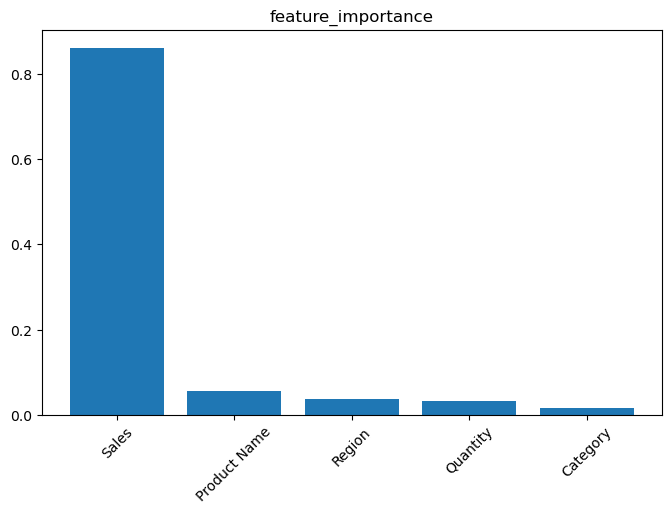

In [110]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'],
       feature_importance['Importance'])
plt.title('feature_importance')
plt.xticks(rotation=45)
plt.show()

# Summary

In [ ]:
# The Ecommerce sales dataset was analyzed to understand sales performance,profit trends,
# customer purchase behavior,and regional performance.Visualization was carried out to 
# identify patterns in sales,categories and profit.A machine learning model RandomForestRegressor was also built
# to predict profits base on business related features.

# Conclusuion

In [ ]:
# The analysis showed that sales and profit vary across product categories and region
# Some product generated higher profit than others,while customer purchase influence revenue
# performance.the machine learning model help estimate profit,although performance depends
# on quality and relevance of the avalaible features.

# Insight

In [ ]:
# High Performance product/categories contribute more to total profit and sales.
# Region based differences suggested some areas generated stronger revenue than othres.
# Quantity purchased influences sales and profit performance.Business can improve 
# profit by focusing on high demand product